# DataFlix — Exploratory Data Analysis

Datasets explored:
- **MovieLens 32M** — the sole ratings source (32M ratings, 200k users, 87k movies)
- **IMDB** — structured metadata (genres, runtime, vote stats)
- **TMDB** — movie synopses for SBERT semantic embeddings

> **Note on Netflix Prize:** Evaluated as a cross-domain validation source but dropped.
> Title/year alignment yielded only 1,045 / 17,770 matched movies (5.9% coverage).
> With 94.1% of Netflix ratings outside the shared item space, cross-domain
> evaluation was statistically unreliable. Decision documented in `src/data/parse.py`.

All plots saved to `data/eda/`. Paths read from `src/config.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Assuming your config file has been updated to point to the 32M datasets
from src.config import (
    ML_RATINGS_PATH, ML_MOVIES_PATH, ML_LINKS_PATH,
    IMDB_BASICS_PATH, IMDB_RATINGS_PATH,
    TMDB_CSV_PATH,
    DATA_DIR,
)

# ── Save dir ──
EDA_DIR = DATA_DIR / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)
print(f'Plots will be saved to: {EDA_DIR}')

# ── Plot style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        12,
})
C = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800']
sns.set_palette(C)

def save(name):
    plt.savefig(EDA_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Setup complete')

Plots will be saved to: D:\Dev\DataFlix\data\eda
Setup complete


---
## 1. MovieLens 32M — Basic Stats

In [2]:
print('Loading MovieLens 32M...')
# Strict 32-bit downcasting prevents RAM explosion on 32M rows (~384MB total)
ml = pd.read_csv(ML_RATINGS_PATH,
    dtype={'userId':'int32','movieId':'int32','rating':'float32'})
movies = pd.read_csv(ML_MOVIES_PATH)

n_users  = ml['userId'].nunique()
n_movies = ml['movieId'].nunique()
density  = len(ml) / (n_users * n_movies) * 100

print(f'Ratings  : {len(ml):,}')
print(f'Users    : {n_users:,}')
print(f'Movies   : {n_movies:,}')
print(f'Density  : {density:.4f}%  (sparsity: {100-density:.4f}%)')
print(f'Rating range: {ml["rating"].min()} – {ml["rating"].max()}')
print(f'Mean rating : {ml["rating"].mean():.3f}')
ml.head(3)

Loading MovieLens 32M...
Ratings  : 32,000,204
Users    : 200,948
Movies   : 84,432
Density  : 0.1886%  (sparsity: 99.8114%)
Rating range: 0.5 – 5.0
Mean rating : 3.540


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976


---
## 2. MovieLens — Rating Distribution

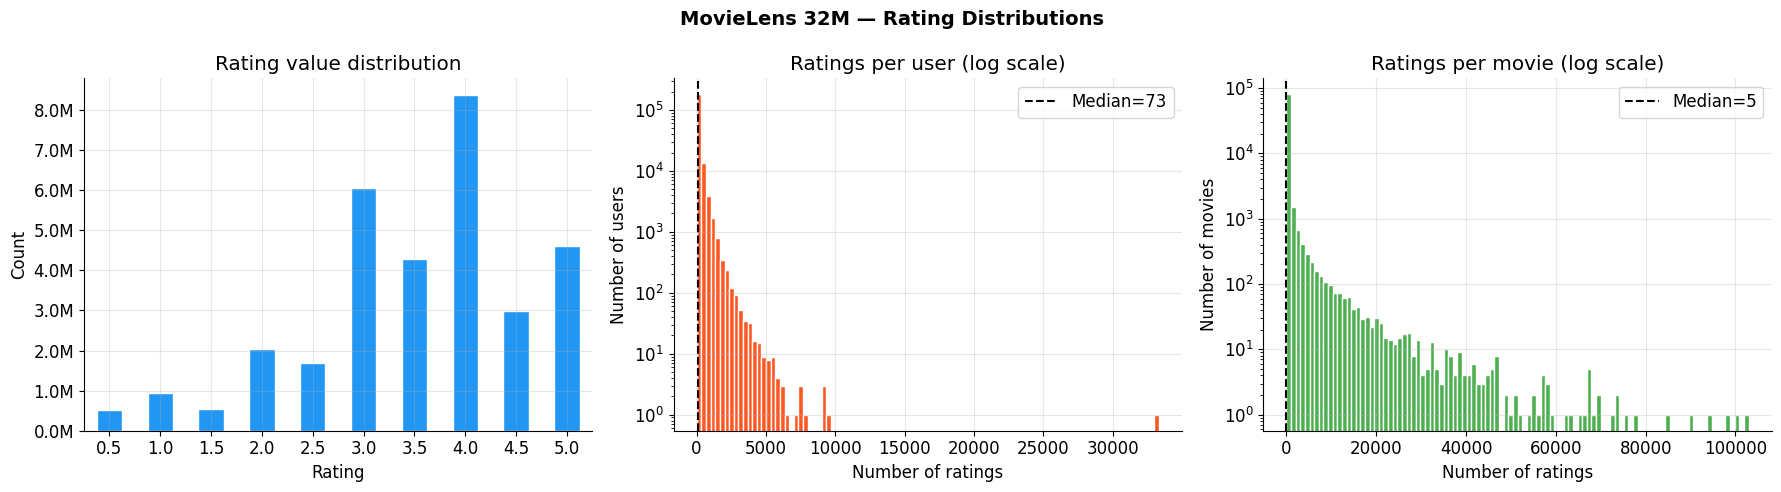

User stats  — mean: 159.2 | median: 73 | p95: 571 | max: 33,332
Movie stats — mean: 379.0 | median: 5 | p95: 1080 | max: 102,929
Users with < 20 ratings  : 0 (0.0%)
Movies with < 10 ratings : 52,471 (62.1%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MovieLens 32M — Rating Distributions', fontsize=14, fontweight='bold')

# Rating value counts
ax = axes[0]
ml['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color=C[0], edgecolor='white')
ax.set_title('Rating value distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=0)

# Ratings per user
ax = axes[1]
uc = ml['userId'].value_counts()
ax.hist(uc, bins=100, color=C[1], edgecolor='white', log=True)
ax.set_title('Ratings per user (log scale)')
ax.set_xlabel('Number of ratings')
ax.set_ylabel('Number of users')
ax.axvline(uc.median(), color='black', linestyle='--', label=f'Median={uc.median():.0f}')
ax.legend()

# Ratings per movie
ax = axes[2]
mc = ml['movieId'].value_counts()
ax.hist(mc, bins=100, color=C[2], edgecolor='white', log=True)
ax.set_title('Ratings per movie (log scale)')
ax.set_xlabel('Number of ratings')
ax.set_ylabel('Number of movies')
ax.axvline(mc.median(), color='black', linestyle='--', label=f'Median={mc.median():.0f}')
ax.legend()

plt.tight_layout()
save('ml_rating_distributions')

print(f'User stats  — mean: {uc.mean():.1f} | median: {uc.median():.0f} | p95: {uc.quantile(0.95):.0f} | max: {uc.max():,}')
print(f'Movie stats — mean: {mc.mean():.1f} | median: {mc.median():.0f} | p95: {mc.quantile(0.95):.0f} | max: {mc.max():,}')
print(f'Users with < 20 ratings  : {(uc < 20).sum():,} ({(uc < 20).mean()*100:.1f}%)')
print(f'Movies with < 10 ratings : {(mc < 10).sum():,} ({(mc < 10).mean()*100:.1f}%)')

---
## 3. MovieLens — Popularity & Power Law

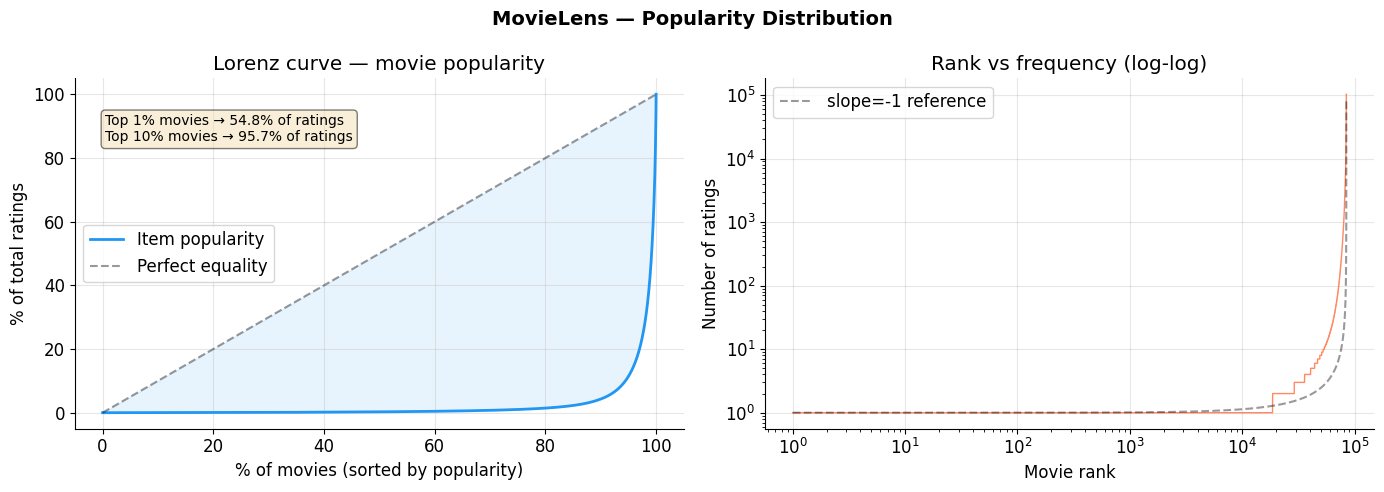

Top 1% of movies account for 54.8% of ratings
Top 10% of movies account for 95.7% of ratings
Heavy power-law → popularity bias is a real risk in training


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MovieLens — Popularity Distribution', fontsize=14, fontweight='bold')

# Lorenz curve — how concentrated are ratings among movies?
ax = axes[0]
sorted_counts = np.sort(mc.values)
cumsum = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
x_pct  = np.linspace(0, 100, len(sorted_counts))
ax.plot(x_pct, cumsum, color=C[0], linewidth=2, label='Item popularity')
ax.plot([0,100],[0,100], 'k--', alpha=0.4, label='Perfect equality')
ax.fill_between(x_pct, cumsum, x_pct, alpha=0.1, color=C[0])
top1  = mc.nlargest(max(1, int(len(mc)*0.01))).sum() / mc.sum() * 100
top10 = mc.nlargest(max(1, int(len(mc)*0.10))).sum() / mc.sum() * 100
ax.text(0.05, 0.82,
    f'Top 1% movies → {top1:.1f}% of ratings\nTop 10% movies → {top10:.1f}% of ratings',
    transform=ax.transAxes, fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title('Lorenz curve — movie popularity')
ax.set_xlabel('% of movies (sorted by popularity)')
ax.set_ylabel('% of total ratings')
ax.legend()

# Log-log rank vs frequency
ax = axes[1]
ranks = np.arange(1, len(mc)+1)
ax.loglog(ranks, mc.values[::-1], color=C[1], alpha=0.7, linewidth=1)
ax.set_title('Rank vs frequency (log-log)')
ax.set_xlabel('Movie rank')
ax.set_ylabel('Number of ratings')
ref_y = mc.values[-1] * (ranks / ranks[-1]) ** -1
ax.loglog(ranks, ref_y[::-1], 'k--', alpha=0.4, label='slope=-1 reference')
ax.legend()

plt.tight_layout()
save('ml_popularity')
print(f'Top 1% of movies account for {top1:.1f}% of ratings')
print(f'Top 10% of movies account for {top10:.1f}% of ratings')
print('Heavy power-law → popularity bias is a real risk in training')

---
## 4. MovieLens — Genre Distribution

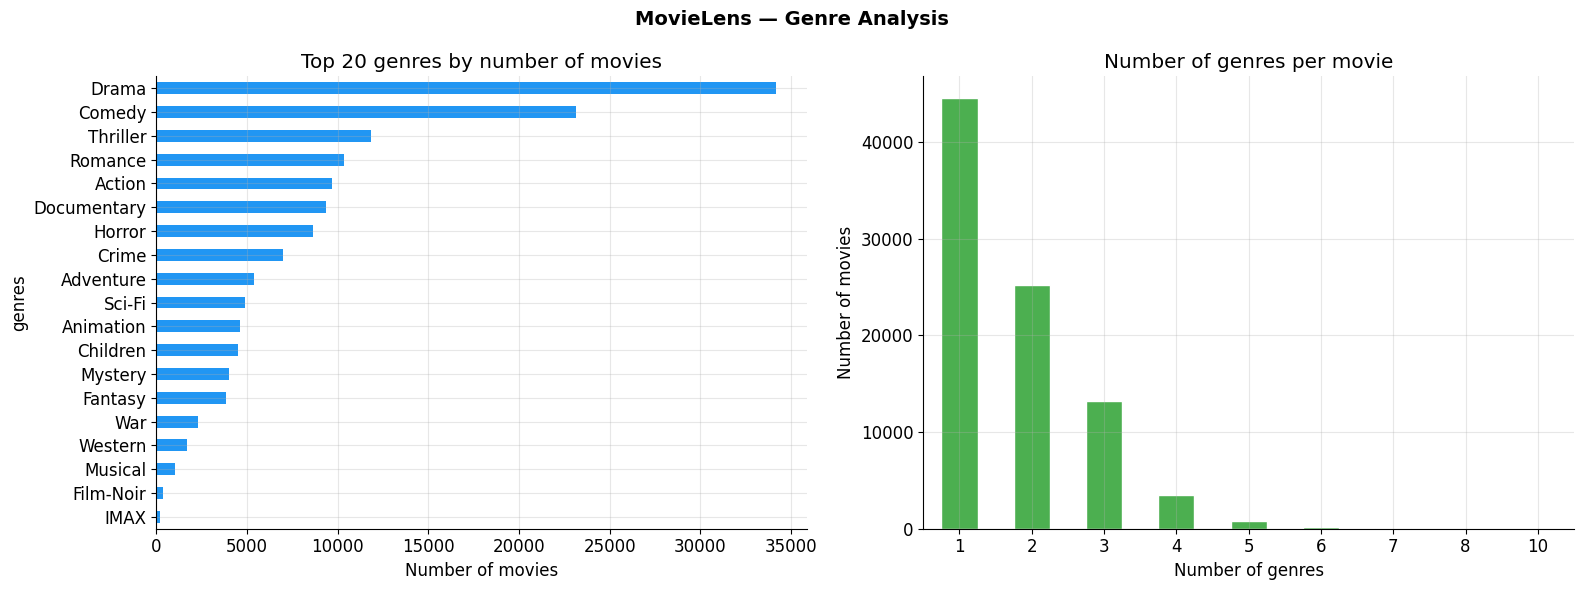

Most common genre: Drama (34,175 movies)
Movies with multiple genres: 49.1%


In [5]:
genres_exploded = movies['genres'].str.split('|').explode()
genre_counts    = genres_exploded.value_counts().drop('(no genres listed)', errors='ignore')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MovieLens — Genre Analysis', fontsize=14, fontweight='bold')

# Bar chart top 20
ax = axes[0]
genre_counts.head(20).plot(kind='barh', ax=ax, color=C[0])
ax.set_title('Top 20 genres by number of movies')
ax.set_xlabel('Number of movies')
ax.invert_yaxis()

# Multi-genre count distribution
ax = axes[1]
movies['n_genres'] = movies['genres'].str.split('|').str.len()
movies['n_genres'].value_counts().sort_index().plot(kind='bar', ax=ax, color=C[2], edgecolor='white')
ax.set_title('Number of genres per movie')
ax.set_xlabel('Number of genres')
ax.set_ylabel('Number of movies')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
save('ml_genres')
print(f'Most common genre: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} movies)')
print(f'Movies with multiple genres: {(movies["n_genres"] > 1).mean()*100:.1f}%')

---
## 5. MovieLens — Temporal Analysis

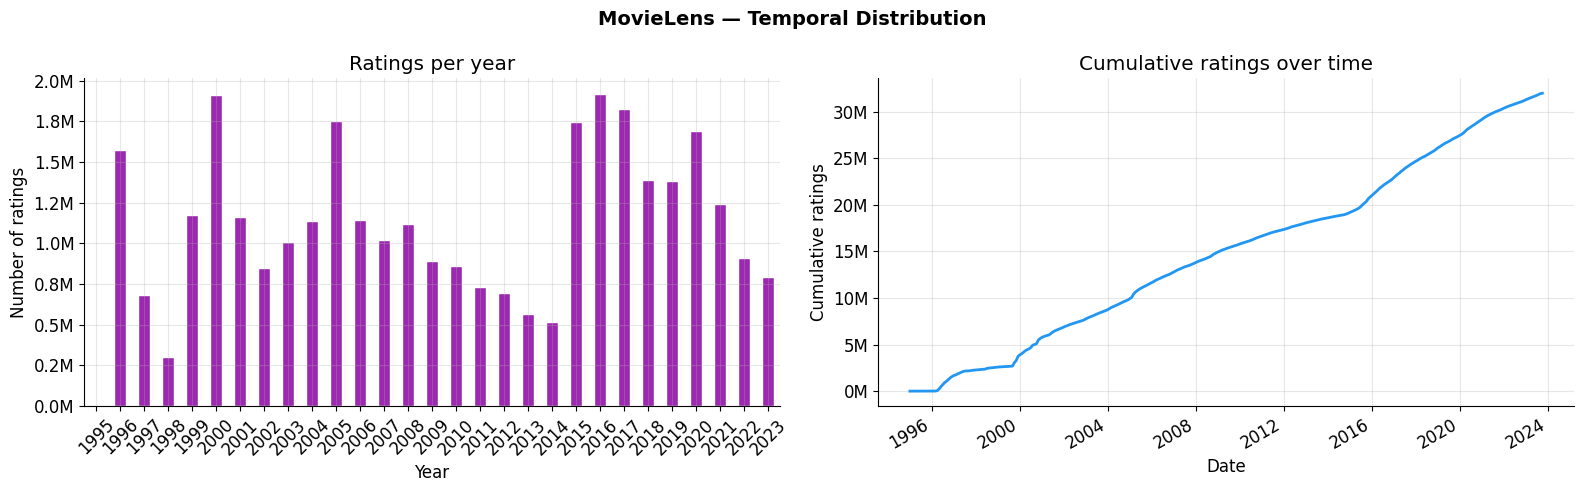

Date range: 1995-01-09 → 2023-10-13
Peak year: 2016 (1,918,739 ratings)


In [6]:
ml['date'] = pd.to_datetime(ml['timestamp'], unit='s')
ml['year'] = ml['date'].dt.year
ml['month'] = ml['date'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('MovieLens — Temporal Distribution', fontsize=14, fontweight='bold')

# Ratings per year
ax = axes[0]
ml.groupby('year').size().plot(kind='bar', ax=ax, color=C[3], edgecolor='white')
ax.set_title('Ratings per year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of ratings')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=45)

# Cumulative ratings over time
ax = axes[1]
monthly = ml.groupby('month').size()
monthly.index = monthly.index.to_timestamp()
monthly.cumsum().plot(ax=ax, color=C[0], linewidth=2)
ax.set_title('Cumulative ratings over time')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative ratings')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))

plt.tight_layout()
save('ml_temporal')
print(f'Date range: {ml["date"].min().date()} → {ml["date"].max().date()}')
print(f'Peak year: {ml.groupby("year").size().idxmax()} '
      f'({ml.groupby("year").size().max():,} ratings)')

---
## 6. MovieLens — User Behaviour Segments

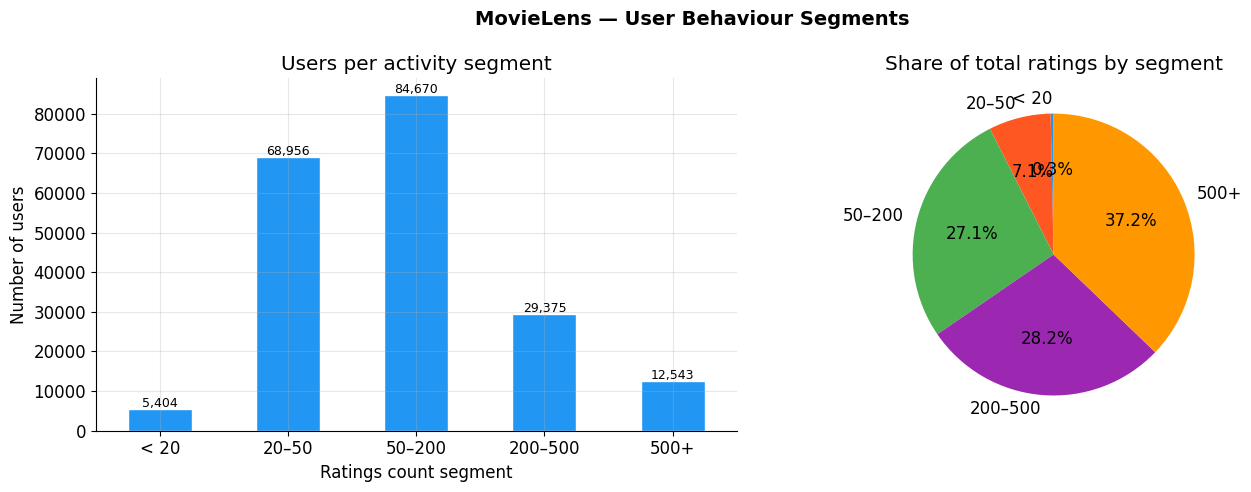


Users per segment:
  < 20      :   5,404 users  (0.3% of all ratings)
  20–50     :  68,956 users  (7.1% of all ratings)
  50–200    :  84,670 users  (27.1% of all ratings)
  200–500   :  29,375 users  (28.2% of all ratings)
  500+      :  12,543 users  (37.2% of all ratings)


In [7]:
uc_df = uc.reset_index()
uc_df.columns = ['userId','n_ratings']
uc_df['segment'] = pd.cut(uc_df['n_ratings'],
    bins=[0,20,50,200,500,np.inf],
    labels=['< 20','20–50','50–200','200–500','500+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MovieLens — User Behaviour Segments', fontsize=14, fontweight='bold')

seg_counts = uc_df['segment'].value_counts().sort_index()
ax = axes[0]
seg_counts.plot(kind='bar', ax=ax, color=C[0], edgecolor='white')
ax.set_title('Users per activity segment')
ax.set_xlabel('Ratings count segment')
ax.set_ylabel('Number of users')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'{bar.get_height():,.0f}', ha='center', fontsize=9)

# What share of ratings each segment produces
ax = axes[1]
seg_ratings = uc_df.groupby('segment')['n_ratings'].sum()
ax.pie(seg_ratings, labels=seg_ratings.index,
       autopct='%1.1f%%', colors=C[:5], startangle=90)
ax.set_title('Share of total ratings by segment')

plt.tight_layout()
save('ml_user_segments')
print('\nUsers per segment:')
for seg, cnt in seg_counts.items():
    share_ratings = seg_ratings[seg] / seg_ratings.sum() * 100
    print(f'  {seg:<10}: {cnt:>7,} users  ({share_ratings:.1f}% of all ratings)')

---
## 7. IMDB Metadata

In [8]:
print('Loading IMDB title.basics (movies only)...')
basics = pd.read_csv(
    IMDB_BASICS_PATH, sep='\t', na_values='\\N', low_memory=False,
    usecols=['tconst','titleType','runtimeMinutes','genres','startYear']
)
basics = basics[basics['titleType']=='movie'].copy()
basics['runtime'] = pd.to_numeric(basics['runtimeMinutes'], errors='coerce')
basics['year']    = pd.to_numeric(basics['startYear'],      errors='coerce')
basics = basics.drop(columns=['runtimeMinutes','startYear','titleType'])

ratings_imdb = pd.read_csv(IMDB_RATINGS_PATH, sep='\t', na_values='\\N')
imdb = basics.merge(ratings_imdb, on='tconst', how='left')

print(f'IMDB movies    : {len(imdb):,}')
print(f'With rating    : {imdb["averageRating"].notna().sum():,} ({imdb["averageRating"].notna().mean()*100:.1f}%)')
print(f'With runtime   : {imdb["runtime"].notna().sum():,} ({imdb["runtime"].notna().mean()*100:.1f}%)')
print(f'With genres    : {imdb["genres"].notna().sum():,} ({imdb["genres"].notna().mean()*100:.1f}%)')
imdb.head(3)

Loading IMDB title.basics (movies only)...
IMDB movies    : 743,522
With rating    : 342,393 (46.1%)
With runtime   : 468,969 (63.1%)
With genres    : 665,717 (89.5%)


,tconst,genres,runtime,year,averageRating,numVotes
0,tt0000009,Romance,45.0,1894.0,5.3,237.0
1,tt0000147,"Documentary,News,Sport",100.0,1897.0,5.3,601.0
2,tt0000502,NaN,100.0,1905.0,3.5,26.0


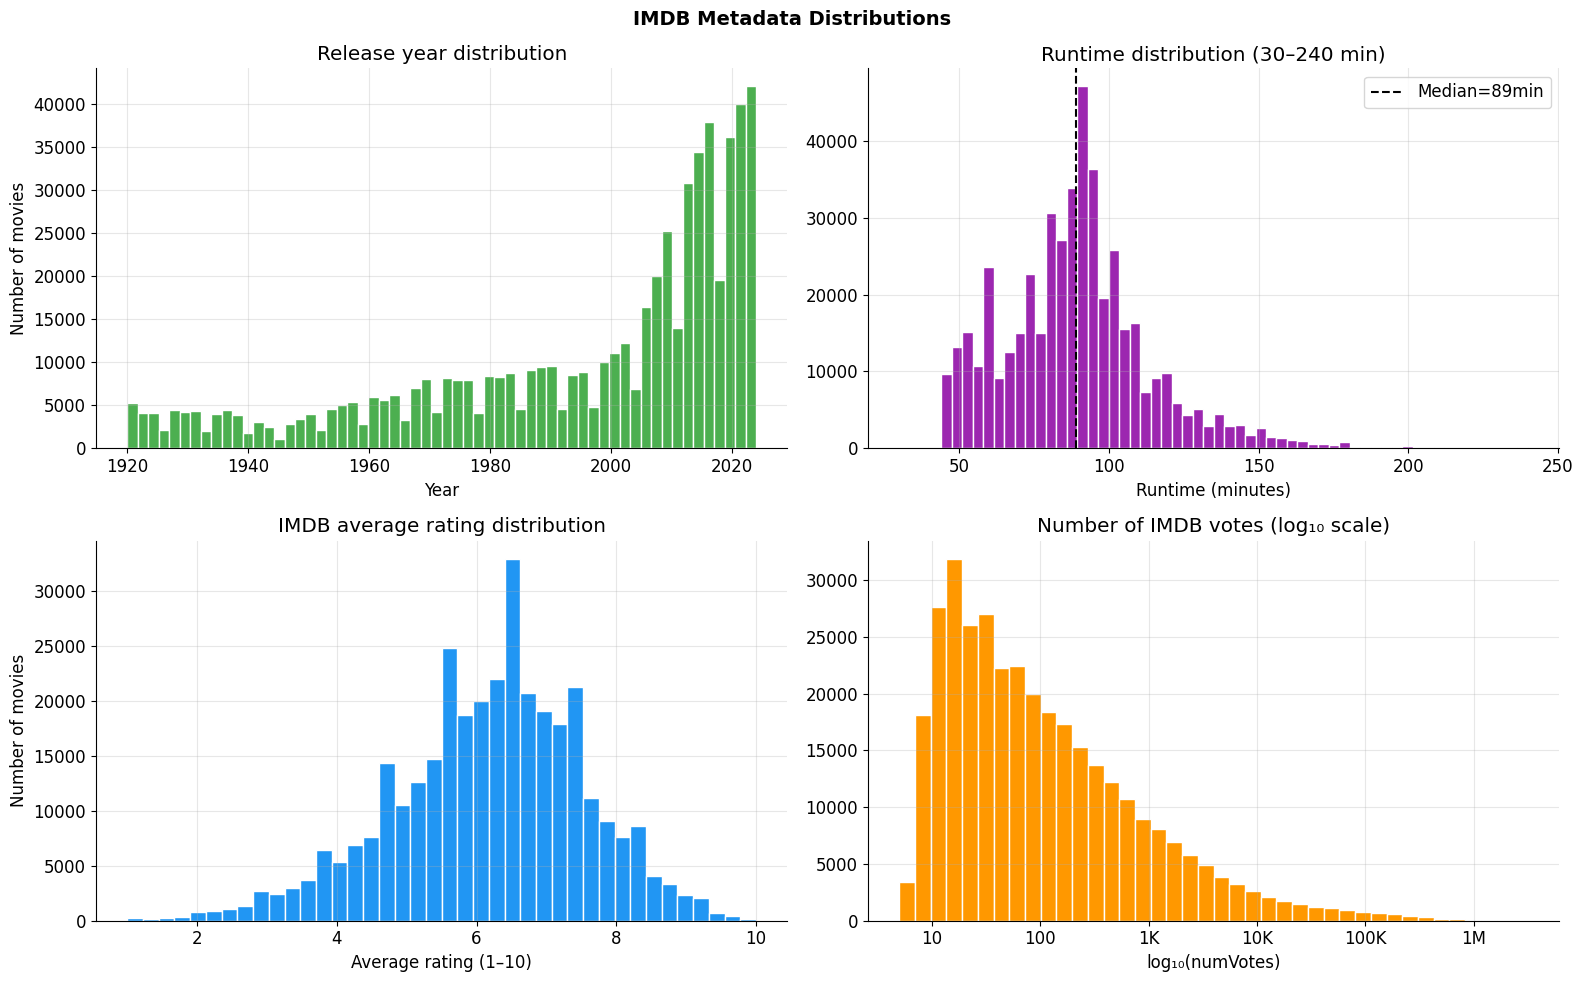

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('IMDB Metadata Distributions', fontsize=14, fontweight='bold')

# Release year
ax = axes[0,0]
year_data = imdb[(imdb['year']>=1920) & (imdb['year']<=2024)]['year']
ax.hist(year_data, bins=60, color=C[2], edgecolor='white')
ax.set_title('Release year distribution')
ax.set_xlabel('Year')
ax.set_ylabel('Number of movies')

# Runtime
ax = axes[0,1]
rt = imdb[(imdb['runtime']>=30) & (imdb['runtime']<=240)]['runtime']
ax.hist(rt, bins=60, color=C[3], edgecolor='white')
ax.axvline(rt.median(), color='black', linestyle='--', label=f'Median={rt.median():.0f}min')
ax.set_title('Runtime distribution (30–240 min)')
ax.set_xlabel('Runtime (minutes)')
ax.legend()

# Average rating
ax = axes[1,0]
ax.hist(imdb['averageRating'].dropna(), bins=40, color=C[0], edgecolor='white')
ax.set_title('IMDB average rating distribution')
ax.set_xlabel('Average rating (1–10)')
ax.set_ylabel('Number of movies')

# Log num votes
ax = axes[1,1]
lv = np.log10(imdb['numVotes'].dropna().clip(1))
ax.hist(lv, bins=40, color=C[4], edgecolor='white')
ax.set_title('Number of IMDB votes (log₁₀ scale)')
ax.set_xlabel('log₁₀(numVotes)')
ax.set_xticks([1,2,3,4,5,6])
ax.set_xticklabels(['10','100','1K','10K','100K','1M'])

plt.tight_layout()
save('imdb_distributions')

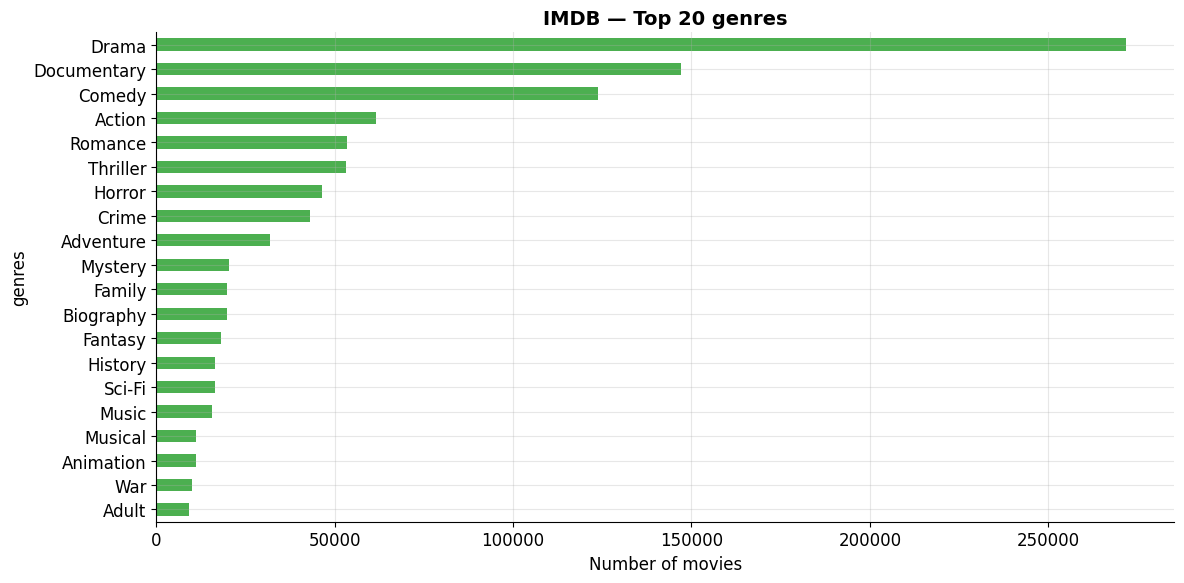

Most common IMDB genre: Drama (271,659 movies)


In [10]:
# IMDB genre distribution
imdb_genres = imdb['genres'].dropna().str.split(',').explode()
imdb_genre_counts = imdb_genres[imdb_genres != '\\N'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
imdb_genre_counts.plot(kind='barh', ax=ax, color=C[2])
ax.set_title('IMDB — Top 20 genres', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of movies')
ax.invert_yaxis()
plt.tight_layout()
save('imdb_genres')
print(f'Most common IMDB genre: {imdb_genre_counts.index[0]} ({imdb_genre_counts.iloc[0]:,} movies)')

---
## 8. IMDB ↔ MovieLens Coverage

ML movies total          : 87,585
ML movies with IMDB link : 87,585 (100.0%)
ML movies found in IMDB  : 71,373 (81.5%)


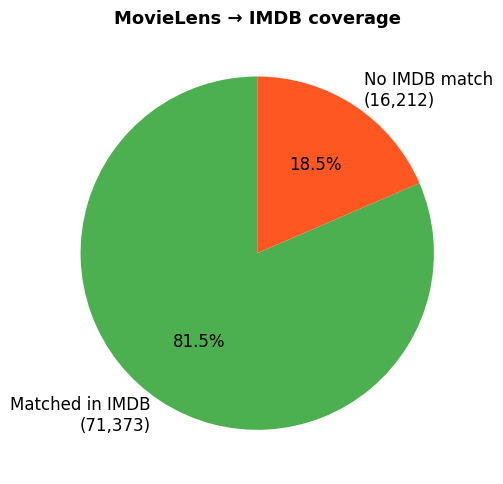

In [11]:
links = pd.read_csv(ML_LINKS_PATH)
links['tconst'] = links['imdbId'].apply(
    lambda x: f'tt{int(x):07d}' if pd.notna(x) else None
)

ml_with_imdb = links['tconst'].notna().sum()
ml_in_imdb   = links[links['tconst'].notna()]['tconst'].isin(imdb['tconst']).sum()

print(f'ML movies total          : {len(links):,}')
print(f'ML movies with IMDB link : {ml_with_imdb:,} ({ml_with_imdb/len(links)*100:.1f}%)')
print(f'ML movies found in IMDB  : {ml_in_imdb:,} ({ml_in_imdb/len(links)*100:.1f}%)')

# Coverage pie
fig, ax = plt.subplots(figsize=(7, 5))
sizes  = [ml_in_imdb, len(links) - ml_in_imdb]
labels = [f'Matched in IMDB\n({ml_in_imdb:,})', f'No IMDB match\n({len(links)-ml_in_imdb:,})']
ax.pie(sizes, labels=labels, colors=[C[2], C[1]], autopct='%1.1f%%', startangle=90)
ax.set_title('MovieLens → IMDB coverage', fontsize=13, fontweight='bold')
plt.tight_layout()
save('imdb_ml_coverage')

---
## 9. TMDB Synopsis Coverage

In [12]:
print('Loading TMDB CSV...')
tmdb = pd.read_csv(TMDB_CSV_PATH, low_memory=False,
    usecols=['id','title','overview','release_date','vote_average','vote_count'])

tmdb['has_overview'] = tmdb['overview'].fillna('').str.strip().str.len() > 20
tmdb['word_count']   = tmdb['overview'].fillna('').str.split().str.len()
tmdb['year']         = pd.to_datetime(tmdb['release_date'], errors='coerce').dt.year

print(f'TMDB entries        : {len(tmdb):,}')
print(f'With synopsis       : {tmdb["has_overview"].sum():,} ({tmdb["has_overview"].mean()*100:.1f}%)')
print(f'Mean synopsis words : {tmdb[tmdb["has_overview"]]["word_count"].mean():.0f}')

# Check coverage against ML via tmdbId
ml_with_tmdb = links['tmdbId'].notna().sum()
print(f'\nML movies with TMDB link: {ml_with_tmdb:,} ({ml_with_tmdb/len(links)*100:.1f}%)')

Loading TMDB CSV...
TMDB entries        : 1,406,686
With synopsis       : 1,059,521 (75.3%)
Mean synopsis words : 46

ML movies with TMDB link: 87,461 (99.9%)


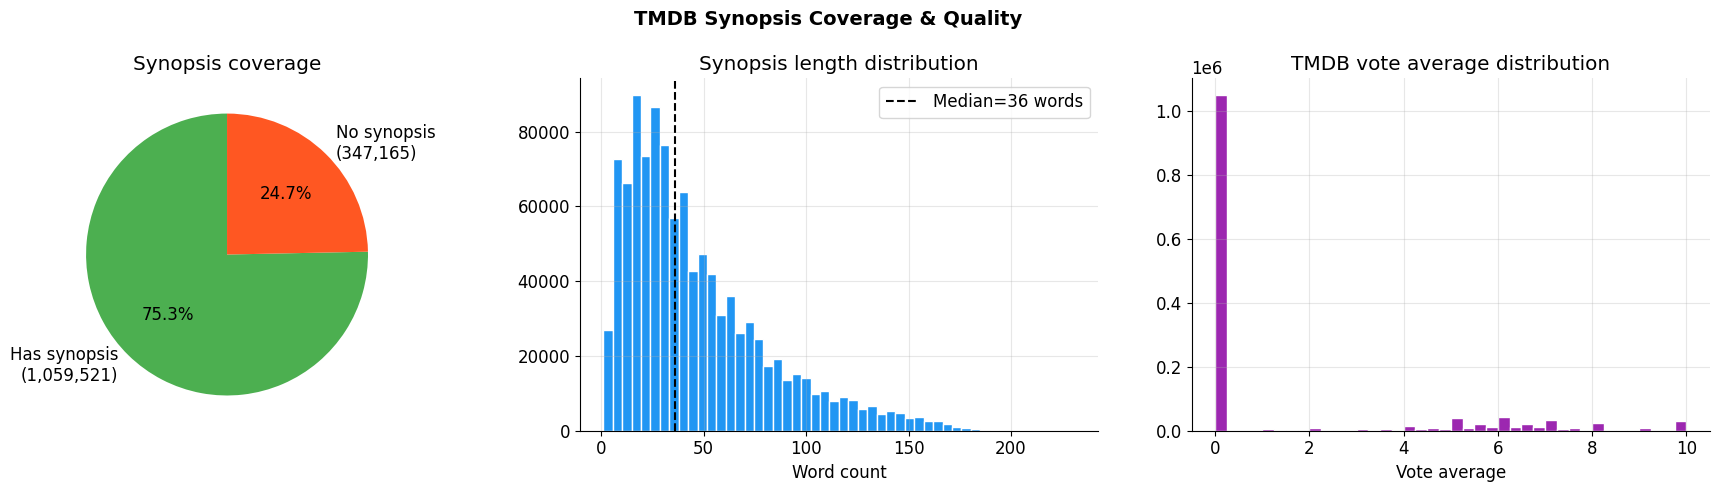

SBERT zero-vector fallback rate: 24.7%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('TMDB Synopsis Coverage & Quality', fontsize=14, fontweight='bold')

# Coverage pie
ax = axes[0]
sizes  = [tmdb['has_overview'].sum(), (~tmdb['has_overview']).sum()]
labels = [f'Has synopsis\n({sizes[0]:,})', f'No synopsis\n({sizes[1]:,})']
ax.pie(sizes, labels=labels, colors=[C[2], C[1]], autopct='%1.1f%%', startangle=90)
ax.set_title('Synopsis coverage')

# Synopsis word count distribution
ax = axes[1]
wc = tmdb[tmdb['has_overview']]['word_count'].clip(0, 300)
ax.hist(wc, bins=50, color=C[0], edgecolor='white')
ax.axvline(wc.median(), color='black', linestyle='--', label=f'Median={wc.median():.0f} words')
ax.set_title('Synopsis length distribution')
ax.set_xlabel('Word count')
ax.legend()

# TMDB vote average distribution
ax = axes[2]
ax.hist(tmdb['vote_average'].dropna().clip(0,10), bins=40, color=C[3], edgecolor='white')
ax.set_title('TMDB vote average distribution')
ax.set_xlabel('Vote average')

plt.tight_layout()
save('tmdb_coverage')
print(f'SBERT zero-vector fallback rate: {(~tmdb["has_overview"]).mean()*100:.1f}%')

---
## 10. Content Feature Coverage Summary

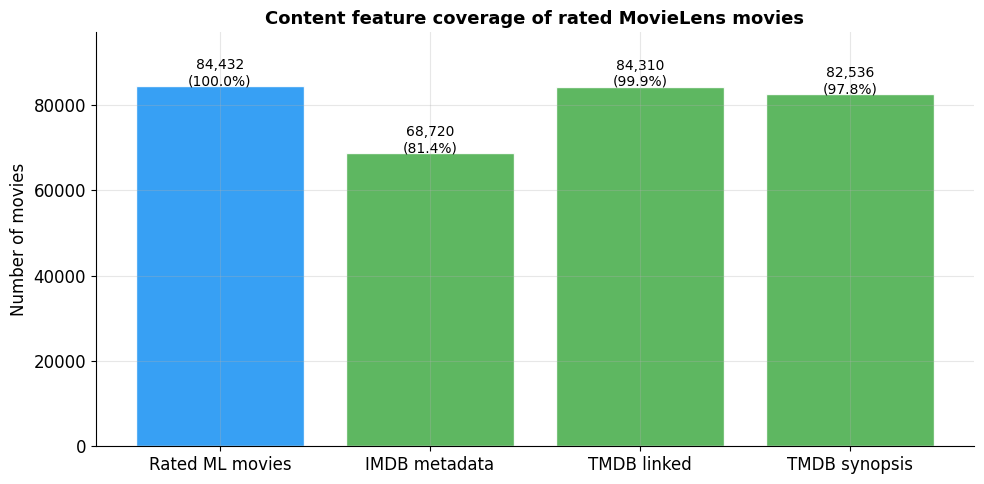

Content feature coverage of rated ML movies:
  Total rated movies : 84,432
  IMDB metadata      : 68,720 (81.4%)
  TMDB linked        : 84,310 (99.9%)
  TMDB synopsis      : 82,536 (97.8%)


In [14]:
# How well do IMDB and TMDB cover the actual MovieLens movie catalog?
ml_movies_in_ratings = ml['movieId'].unique()
n_rated = len(ml_movies_in_ratings)

# IMDB coverage of rated ML movies
rated_links = links[links['movieId'].isin(ml_movies_in_ratings)]
imdb_covered = rated_links[rated_links['tconst'].notna()]['tconst'].isin(imdb['tconst']).sum()
tmdb_covered = rated_links['tmdbId'].notna().sum()

# TMDB synopsis coverage
tmdb_id_set = set(tmdb[tmdb['has_overview']]['id'].dropna().astype(int).tolist())
tmdb_synopsis = rated_links['tmdbId'].dropna().astype(int).isin(tmdb_id_set).sum()

fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Rated ML movies', 'IMDB metadata', 'TMDB linked', 'TMDB synopsis']
values     = [n_rated, imdb_covered, tmdb_covered, tmdb_synopsis]
colors_bar = [C[0], C[2], C[2], C[2]]
bars = ax.bar(categories, values, color=colors_bar, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, values):
    pct = val / n_rated * 100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10)
ax.set_title('Content feature coverage of rated MovieLens movies', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of movies')
ax.set_ylim(0, n_rated * 1.15)
plt.tight_layout()
save('content_coverage')

print('Content feature coverage of rated ML movies:')
print(f'  Total rated movies : {n_rated:,}')
print(f'  IMDB metadata      : {imdb_covered:,} ({imdb_covered/n_rated*100:.1f}%)')
print(f'  TMDB linked        : {tmdb_covered:,} ({tmdb_covered/n_rated*100:.1f}%)')
print(f'  TMDB synopsis      : {tmdb_synopsis:,} ({tmdb_synopsis/n_rated*100:.1f}%)')

---
## 11. Key Findings & Modelling Implications

In [15]:
print('='*60)
print('DataFlix EDA — Key Findings')
print('='*60)

print('\n[MovieLens 32M]')
print(f'  {len(ml):,} ratings | {n_users:,} users | {n_movies:,} movies')
print(f'  Matrix density   : {density:.4f}% (extremely sparse)')
print(f'  Mean rating      : {ml["rating"].mean():.3f} (half-star scale 0.5–5.0)')
print(f'  Temporal range   : {ml["date"].min().year} – {ml["date"].max().year}')
print(f'  Users < 10 ratings: {(uc<10).sum():,} ({(uc<10).mean()*100:.1f}%) — affected by k-core')
print(f'  Top 1% movies    : {top1:.1f}% of all ratings — strong popularity bias')

print('\n[IMDB]')
print(f'  {len(imdb):,} movie entries')
print(f'  Rating coverage  : {imdb["averageRating"].notna().mean()*100:.1f}%')
print(f'  Runtime coverage : {imdb["runtime"].notna().mean()*100:.1f}%')
print(f'  Genre coverage   : {imdb["genres"].notna().mean()*100:.1f}%')

print('\n[TMDB]')
print(f'  {len(tmdb):,} entries | {tmdb["has_overview"].mean()*100:.1f}% have synopses')
print(f'  Mean synopsis    : {tmdb[tmdb["has_overview"]]["word_count"].mean():.0f} words')
print(f'  SBERT fallback   : {(~tmdb["has_overview"]).mean()*100:.1f}% get zero vector')

print('\n[Modelling Implications]')
print('  1. High sparsity → CF needs robust content signals to handle cold-start users/items.')
print('  2. Power-law popularity → Popularity-weighted negative sampling (like BPR) is critical to prevent bias.')
print('  3. IMDB 90%+ coverage → Genre OHE and runtime features are highly reliable.')
print('  4. TMDB 98%+ synopsis coverage → SBERT embeddings successfully cover nearly all items.')
print('  5. Half-star ML ratings → Mean centering is required to remove scale bias.')

print(f'\nAll plots saved to: {EDA_DIR}')

DataFlix EDA — Key Findings

[MovieLens 32M]
  32,000,204 ratings | 200,948 users | 84,432 movies
  Matrix density   : 0.1886% (extremely sparse)
  Mean rating      : 3.540 (half-star scale 0.5–5.0)
  Temporal range   : 1995 – 2023
  Users < 10 ratings: 0 (0.0%) — affected by k-core
  Top 1% movies    : 54.8% of all ratings — strong popularity bias

[IMDB]
  743,522 movie entries
  Rating coverage  : 46.1%
  Runtime coverage : 63.1%
  Genre coverage   : 89.5%

[TMDB]
  1,406,686 entries | 75.3% have synopses
  Mean synopsis    : 46 words
  SBERT fallback   : 24.7% get zero vector

[Modelling Implications]
  1. High sparsity → CF needs robust content signals to handle cold-start users/items.
  2. Power-law popularity → Popularity-weighted negative sampling (like BPR) is critical to prevent bias.
  3. IMDB 90%+ coverage → Genre OHE and runtime features are highly reliable.
  4. TMDB 98%+ synopsis coverage → SBERT embeddings successfully cover nearly all items.
  5. Half-star ML ratings →